In [1]:
import csv
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from connect4.connect_state import ConnectState
from connect4.policy import Policy
from groups.Group_A.policy import SebastianAgent
from groups.Group_A_1.policy import SebastianAgent2
from groups.Group_C.policy import RandomAgent
from groups.Group_B.policy import juanes_agente

In [3]:
def play_game(agent_A: Policy, agent_B: Policy, A_starts: bool):
    agent_A.mount()
    agent_B.mount()

    board = np.zeros((6, 7), dtype=int)
    state = ConnectState(board=board)

    decision_times_A = []
    moves = 0

    sign_A = -1 if A_starts else 1
    sign_B = -sign_A

    while not state.is_final():
        current_board = state.board
        current_player = state.player

        if current_player == sign_A:
            current_agent = agent_A
            medir_A = True
        else:
            current_agent = agent_B
            medir_A = False

        if medir_A:
            t0 = time.perf_counter()
            action = current_agent.act(current_board)
            t1 = time.perf_counter()
            decision_times_A.append(t1 - t0)
        else:
            action = current_agent.act(current_board)

        state = state.transition(int(action))
        moves += 1

    winner = state.get_winner()

    if winner == 0:
        result = "draw"
    elif winner == sign_A:
        result = "A"
    else:
        result = "B"

    avg_A = sum(decision_times_A) / len(decision_times_A) if decision_times_A else 0.0
    max_A = max(decision_times_A) if decision_times_A else 0.0

    return result, moves, avg_A, max_A


def run_benchmark(agent_A, agent_B, num_games=200):
    rows = []
    for i in range(num_games):
        A_starts = i < num_games // 2
        result, moves, avg_dt, max_dt = play_game(agent_A, agent_B, A_starts)
        rows.append(
            {
                "game_id": i,
                "A_starts": A_starts,
                "winner": result,
                "num_moves": moves,
                "avg_decision_time_A": avg_dt,
                "max_decision_time_A": max_dt,
            }
        )
    return pd.DataFrame(rows)

In [67]:
def estadisticas(df):
    total_games = len(df)
    win_A = (df["winner"] == "A").sum()
    print(win_A)

    win_B = (df["winner"] == "B").sum()
    print(win_B)
    draws = (df["winner"] == "draw").sum()

    print("Total partidas:", total_games)
    print("A:", win_A, win_A/total_games*100,"%")
    print("B:", win_B, win_B/total_games*100, "%")
    print("Empates: ", draws, draws/total_games*100, "%")
#FIGURA DE DISTRIBUCION DE MOVIMIENTOS
    plt.figure()
    df["num_moves"].hist(bins=15)
    plt.xlabel("Número de movimientos")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de movimientos por partida")
    plt.tight_layout()
    plt.show()
#FIGURA DE DISTRIBUCION DE TIEMPO PROMEDIO POR DECISION
    plt.figure()
    df["avg_decision_time_A"].hist(bins=15)
    plt.xlabel("Tiempo promedio por decisión (ms)")
    plt.ylabel("Frecuencia")
    plt.title("Distribución del tiempo promedio por decisión")
    plt.tight_layout()
    plt.show()
#RESULTADOS DE PARTIDOS
    labels = ["A", "B", "Empate"]
    winrates = [
        win_A / total_games * 100,
        win_B / total_games * 100,
        draws / total_games * 100,
    ]

    plt.figure()
    plt.bar(labels, winrates)
    plt.ylabel("Porcentaje de partidas (%)")
    plt.title("Resultados de las partidas")
    plt.tight_layout()
    plt.show()


# Pruebas de agente sebastian 1 contra random

In [69]:

df = run_benchmark(SebastianAgent(), RandomAgent(), 50)
df.head()

,game_id,A_starts,winner,num_moves,avg_decision_time_A,max_decision_time_A
0,0,True,A,9,0.118067,0.228772
1,1,True,A,9,0.119550,0.226722
2,2,True,A,7,0.089083,0.193419
3,3,True,A,9,0.110981,0.192936
4,4,True,A,13,0.125127,0.196793


50
0
Total partidas: 50
A: 50 100.0 %
B: 0 0.0 %
Empates:  0 0.0 %


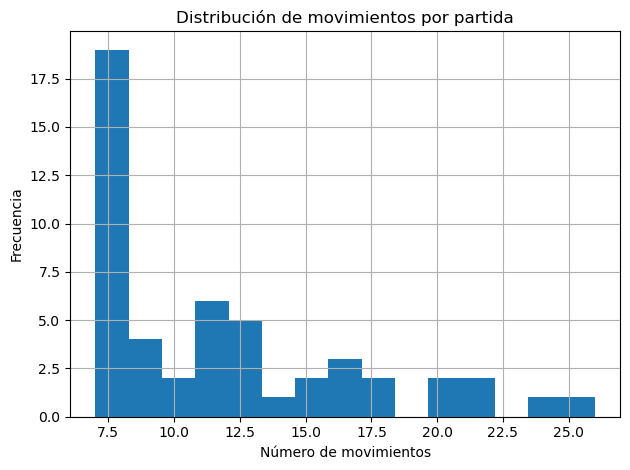

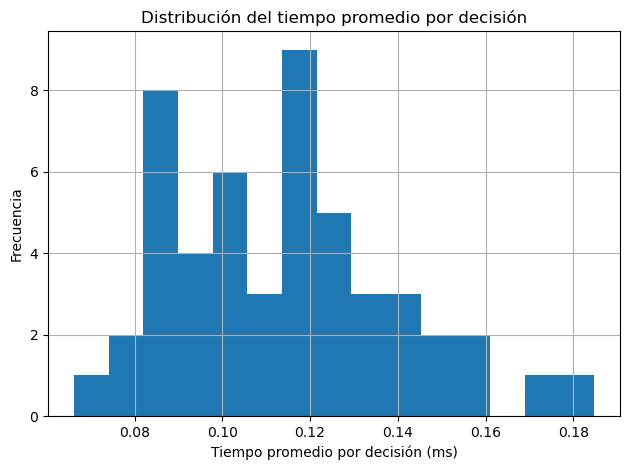

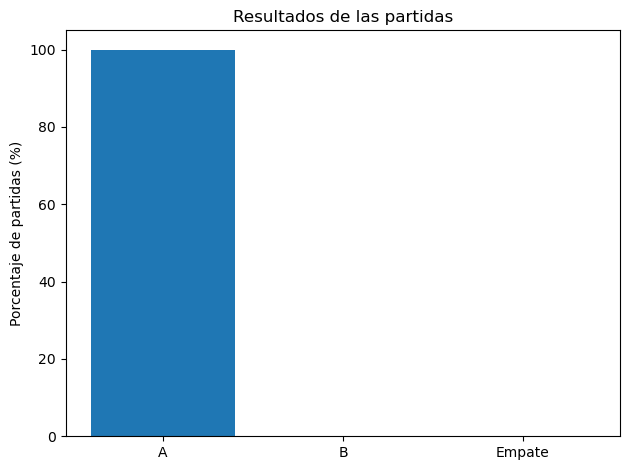

In [70]:
estadisticas(df)

# Prueba agente Sebastian 2 contra random

50
0
Total partidas: 50
A: 50 100.0 %
B: 0 0.0 %
Empates:  0 0.0 %


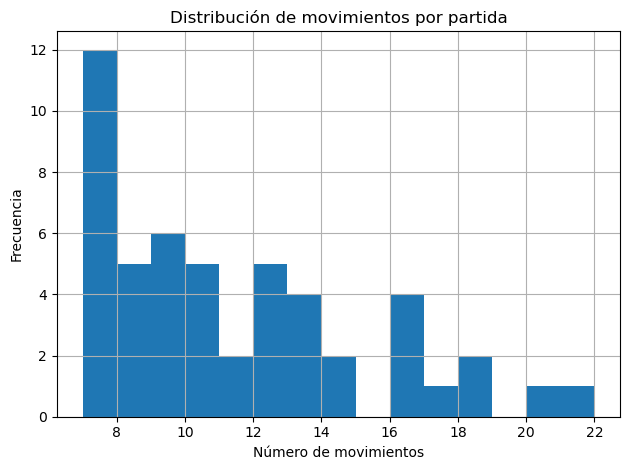

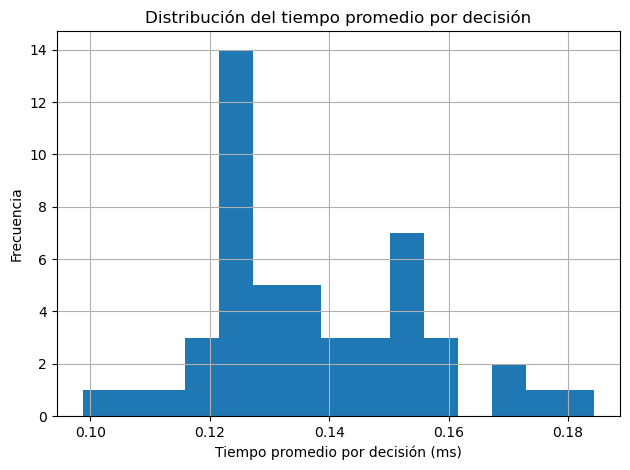

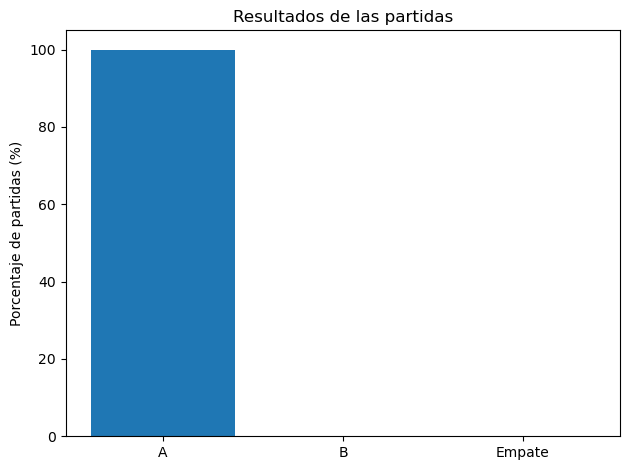

In [71]:
df = run_benchmark(SebastianAgent2(), RandomAgent(), 50)
estadisticas(df)


# Prueba sebastian 1 pero con 400 simulaciones

50
0
Total partidas: 50
A: 50 100.0 %
B: 0 0.0 %
Empates:  0 0.0 %


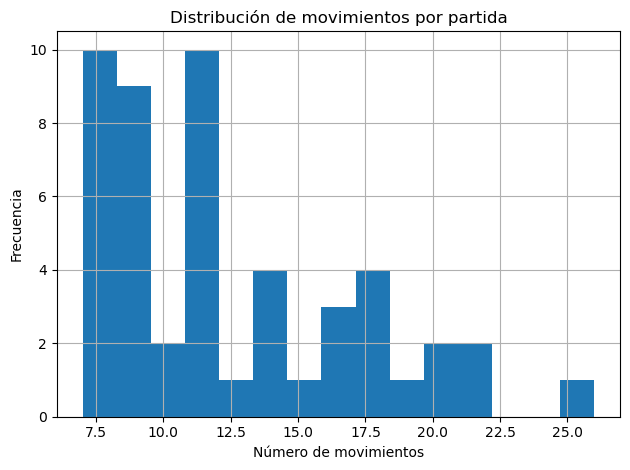

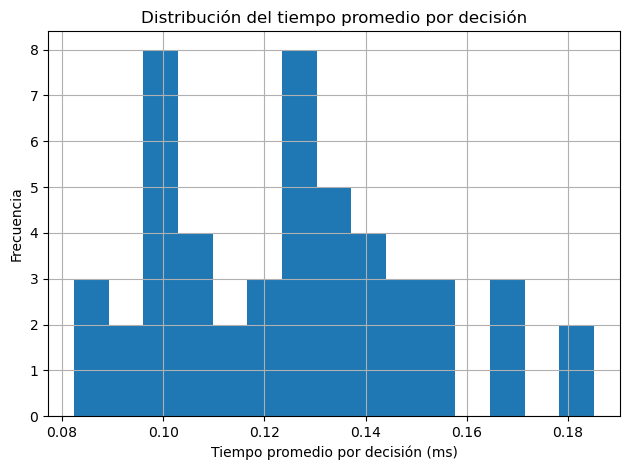

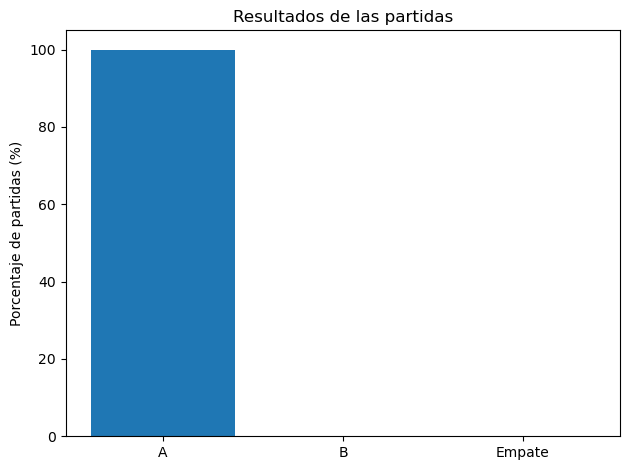

In [74]:
df = run_benchmark(SebastianAgent(), RandomAgent(), 50)
estadisticas(df)

# Prueba sebastian 2 pero con 400 simulaciones

49
1
Total partidas: 50
A: 49 98.0 %
B: 1 2.0 %
Empates:  0 0.0 %


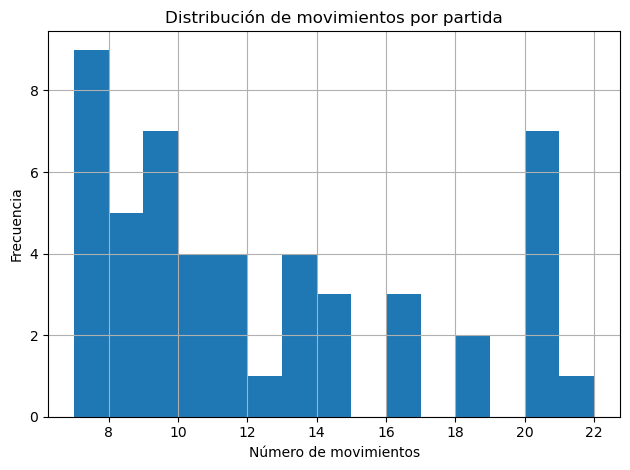

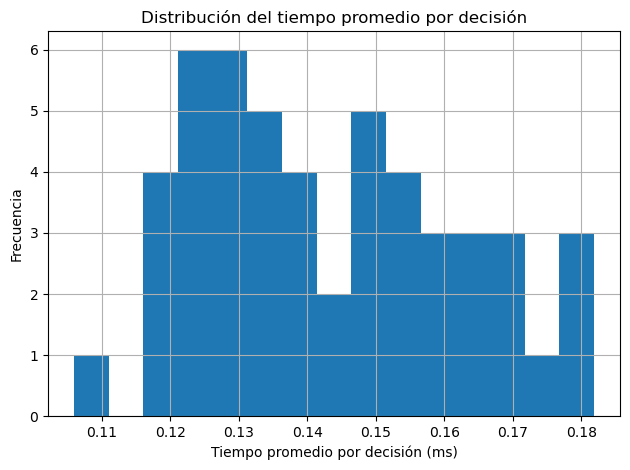

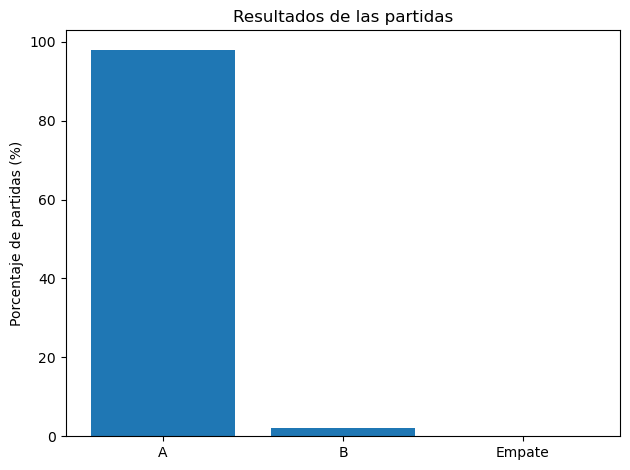

In [75]:
df = run_benchmark(SebastianAgent2(), RandomAgent(), 50)
estadisticas(df)

68
30
Total partidas: 100
A: 68 68.0 %
B: 30 30.0 %
Empates:  2 2.0 %


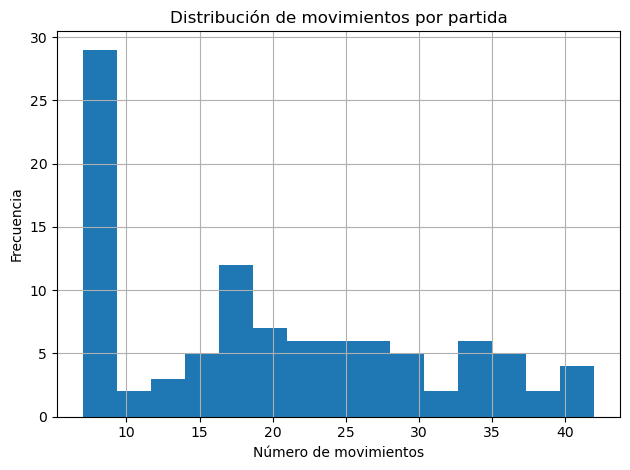

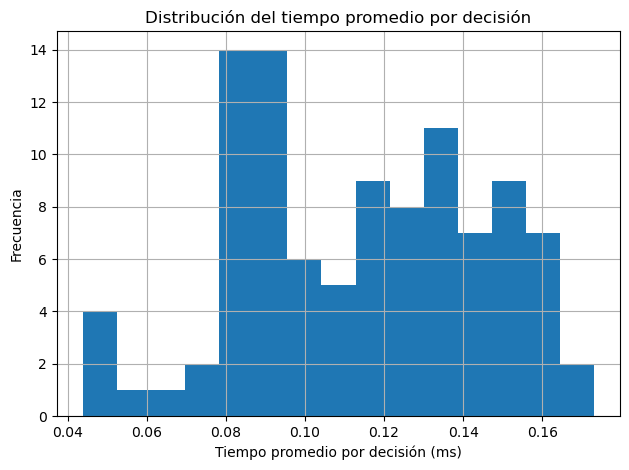

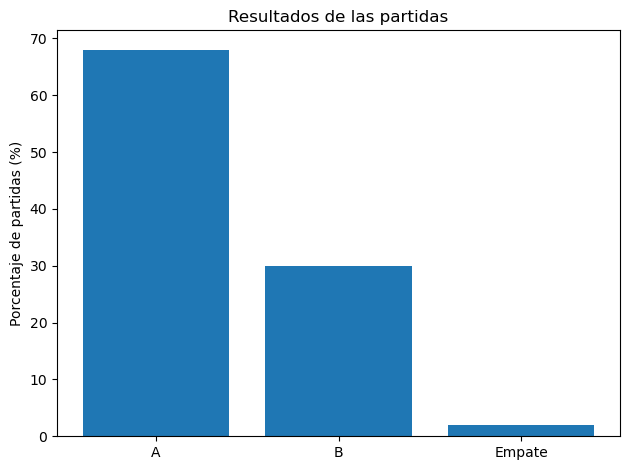

In [76]:
df = run_benchmark(SebastianAgent(), SebastianAgent2(), 100)
estadisticas(df)

 # Prueba Agente Sebastian 1 vs agente de Juanes final

In [ ]:
df = run_benchmark(juanes_agente(), SebastianAgent(), 100)
estadisticas(df)